In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import shap
import dice_ml

import warnings
warnings.filterwarnings('ignore')

/home/sargarz/xai/xai_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# DATA LOADING AND PREPROCESSING

# Ensure you have 'german_credit_data.csv' in the same folder
df = pd.read_csv("german_credit_data.csv", index_col=0)

# Fill missing values with 'Unknown' to retain all data points
df.fillna("Unknown", inplace=True)

# Convert the Target Variable to binary (1 = Good Risk/Approved, 0 = Bad Risk/Denied)
df['Risk'] = df['Risk'].map({'good': 1, 'bad': 0})

# Define feature types for the pipeline
categorical_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
numerical_features = ['Age', 'Job', 'Credit amount', 'Duration']

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Split data into features (X) and target (y)
X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# MODEL TRAINING

# Use a Random Forest Classifier as 'Black-Box' model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Create the full pipeline
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', rf_model)])

# Train the model
clf.fit(X_train, y_train)

# Evaluate the model
y_pred = clf.predict(X_test)
print("MODEL PERFORMANCE:")
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

MODEL PERFORMANCE:
Model Accuracy: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.47      0.54        59
           1       0.80      0.88      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200




SHAP Explanations:


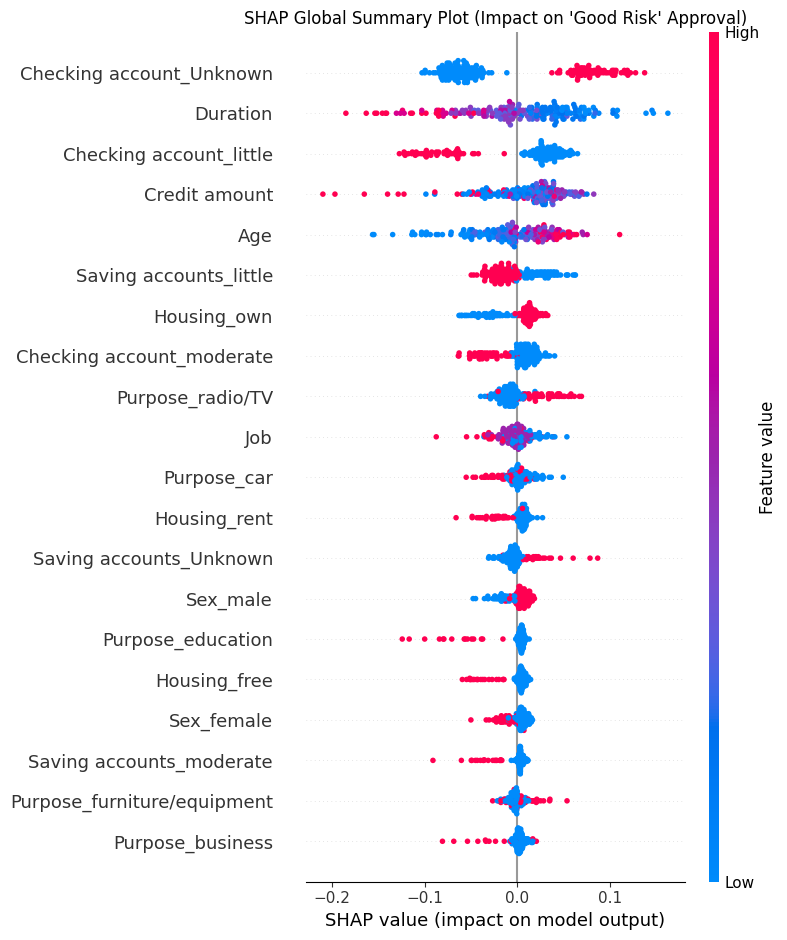

In [4]:
# EXPLANATION METHOD 1: SHAP (Global Bias Detection)

print("\nSHAP Explanations:")
shap.initjs()

# Extract preprocessed data for SHAP
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(clf.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_df)

# Handle different SHAP versions (list vs 3D array)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1] 
else:
    shap_values_to_plot = shap_values[:, :, 1] 

# Plot 1: SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Summary Plot (Impact on 'Good Risk' Approval)")
shap.summary_plot(shap_values_to_plot, X_test_df, show=False) 
plt.show()

In [5]:
# EXPLANATION METHOD 2: DiCE (Targeted Bias Audit)
print("\Isolated Counterfactuals (Targeted Bias Audit):")

# Step A: Initialize DiCE objects
train_dataset = X_train.copy()
train_dataset['Risk'] = y_train
d = dice_ml.Data(dataframe=train_dataset, continuous_features=numerical_features, outcome_name='Risk')
m = dice_ml.Model(model=clf, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")

# Step B: Filter for denied female applicants
X_test_with_preds = X_test.copy()
X_test_with_preds['Predicted_Risk'] = y_pred
denied_females = X_test_with_preds[(X_test_with_preds['Predicted_Risk'] == 0) & (X_test_with_preds['Sex'] == 'female')]
denied_females = denied_females.drop(columns=['Predicted_Risk'])

print(f"Found {len(denied_females)} denied female applicants in the test set.")

if not denied_females.empty:
    
    # Trackers for our global evaluation
    sex_flip_count = 0
    age_flip_count = 0
    
    print("\nRunning global bias audit over all denied female applicants")
    
    for index, applicant in denied_females.iterrows():
        # Convert single row to DataFrame
        applicant_df = pd.DataFrame([applicant])
        
        # --- TEST 1: ISOLATED SEX BIAS ---
        try:
            cf_sex = exp.generate_counterfactuals(applicant_df, total_CFs=1, desired_class="opposite", features_to_vary=['Sex'])
            if cf_sex.cf_examples_list[0].final_cfs_df is not None:
                sex_flip_count += 1
        except Exception:
            pass # No counterfactual found for sex change

        # --- TEST 2: ISOLATED AGE BIAS ---
        try:
            cf_age = exp.generate_counterfactuals(applicant_df, total_CFs=1, desired_class="opposite", features_to_vary=['Age'])
            if cf_age.cf_examples_list[0].final_cfs_df is not None:
                age_flip_count += 1
        except Exception:
            pass # No counterfactual found for age change

    # Step C: Print aggregate results for the report
    print("\nBias Audit Results:")
    print(f"Total Denied Female Applicants Audited: {len(denied_females)}")
    print(f"Decisions flipped by changing ONLY Sex: {sex_flip_count} ({(sex_flip_count/len(denied_females))*100:.2f}%)")
    print(f"Decisions flipped by changing ONLY Age: {age_flip_count} ({(age_flip_count/len(denied_females))*100:.2f}%)")
    
    # Show one visual example just for the code demonstration
    print("\nShowing visual example for the first applicant:")
    sample = denied_females.head(1)
    cf_example = exp.generate_counterfactuals(sample, total_CFs=1, desired_class="opposite", features_to_vary=['Age'])
    cf_example.visualize_as_dataframe(show_only_changes=True)

else:
    print("No denied female applicants found in the test set.")

\Isolated Counterfactuals (Targeted Bias Audit):
Found 12 denied female applicants in the test set.

Running global bias audit over all denied female applicants


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 18.27it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|                                                     | 0/1 [00:00<?, ?it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters...

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 17.55it/s]


 ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 19.02it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 18.53it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  7.98it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 19.40it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 17.56it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 16.29it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 17.17it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 16.11it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 18.03it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 17.77it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|                                                     | 0/1 [00:00<?, ?it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters...

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 18.14it/s]


 ; total time taken: 00 min 00 sec


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 12.16it/s]



Bias Audit Results:
Total Denied Female Applicants Audited: 12
Decisions flipped by changing ONLY Sex: 2 (16.67%)
Decisions flipped by changing ONLY Age: 9 (75.00%)

Showing visual example for the first applicant:


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 12.48it/s]

Query instance (original outcome : 0)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,24,female,2,rent,little,little,2124,18,furniture/equipment,0



Diverse Counterfactual set (new outcome: 1)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,58,-,-,-,-,-,-,-,-,1
